<a href="https://colab.research.google.com/github/Jadonsofficiall/Google-Colab/blob/main/Marvis_Sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Loading data

In [2]:
df = pd.read_excel('Mavis_Store.xlsx')

**# Data Cleaning and Feature Engineering**
*## Convert data to understand time format*

In [3]:
df['Date'] = pd.to_datetime(df['Date'])

In [4]:
df['Year'] = df['Date'].dt.year

# Calculate Financials (CRITICAL STEP for Analysts)

In [5]:
df['Revenue'] = df['Order Quantity'] * df['Unit Price']

In [6]:
df['Total_Cost'] = df['Order Quantity'] * df['Unit Cost']

In [7]:
df['Profit'] = df['Revenue'] - df['Total_Cost']

# Answering Objective 1: The Trend

In [8]:
trend = df.groupby('Year')[['Revenue', 'Profit']].sum()
print("--- Annual Trend ---")
print(trend)

--- Annual Trend ---
       Revenue   Profit
Year                   
2011  10065457  3981870
2012  10289670  4065680
2013  17028380  7747551
2014  15705990  7417353
2015  22405052  9909624
2016  19681769  9004332


# Answering Objective 2: Product Mix

In [9]:
products = df.groupby('Sub Category')[['Order Quantity', 'Profit']].sum().sort_values(by='Profit', ascending=False)
print("\n--- Top Profit Drivers ---")
print(products.head(5))


--- Top Profit Drivers ---
                 Order Quantity    Profit
Sub Category                             
Road Bikes                19771  14172643
Mountain Bikes            11992  10719086
Helmets                  181606   3995332
Tires and Tubes          514051   3223589
Touring Bikes              4648   3053609


# Export for Looker Studio
*## We save this cleaned data to visualize it later*

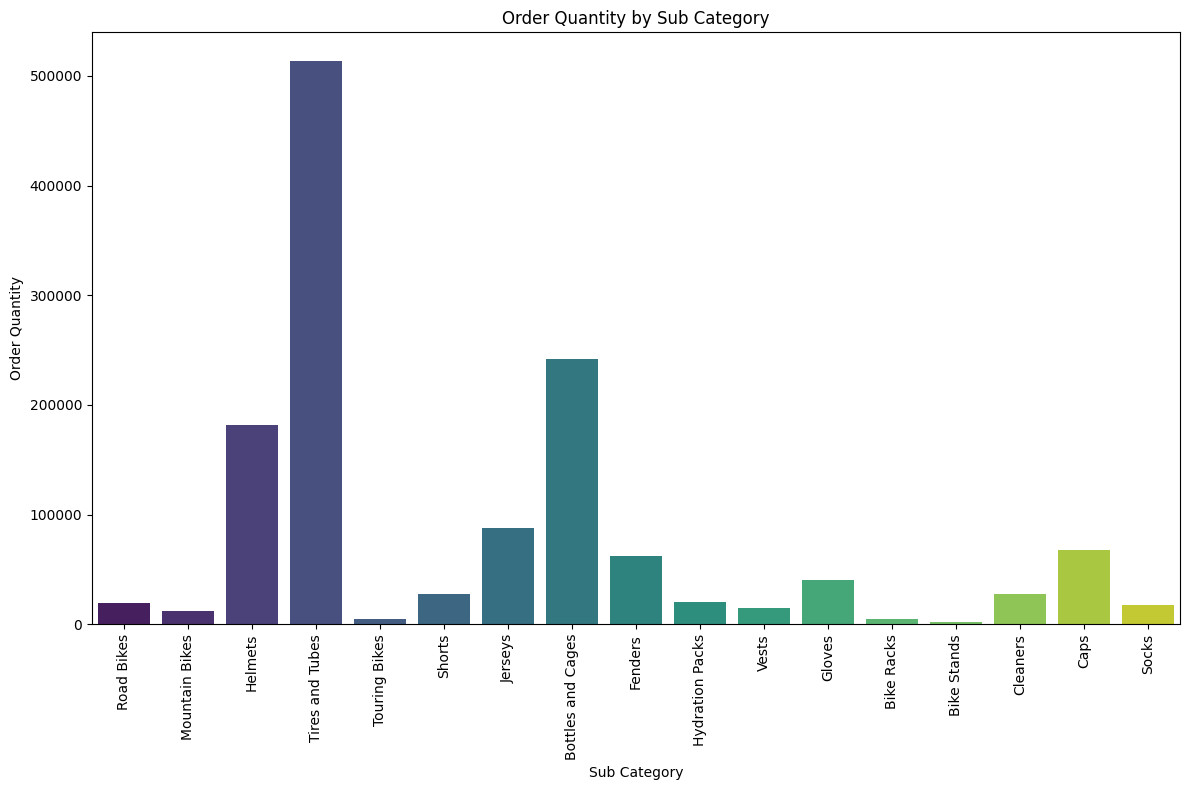

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(x=products.index, y=products['Order Quantity'], palette='viridis', hue=products.index, legend=False)
plt.title('Order Quantity by Sub Category')
plt.xlabel('Sub Category')
plt.ylabel('Order Quantity')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

This bar chart displays the total 'Order Quantity' for each product 'Sub Category', sorted by profit in descending order (as per the `products` DataFrame sorting). This helps in understanding which categories have the highest sales volume.

/tmp/ipython-input-1515685245.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=products.index, y=products['Profit'], palette='viridis')


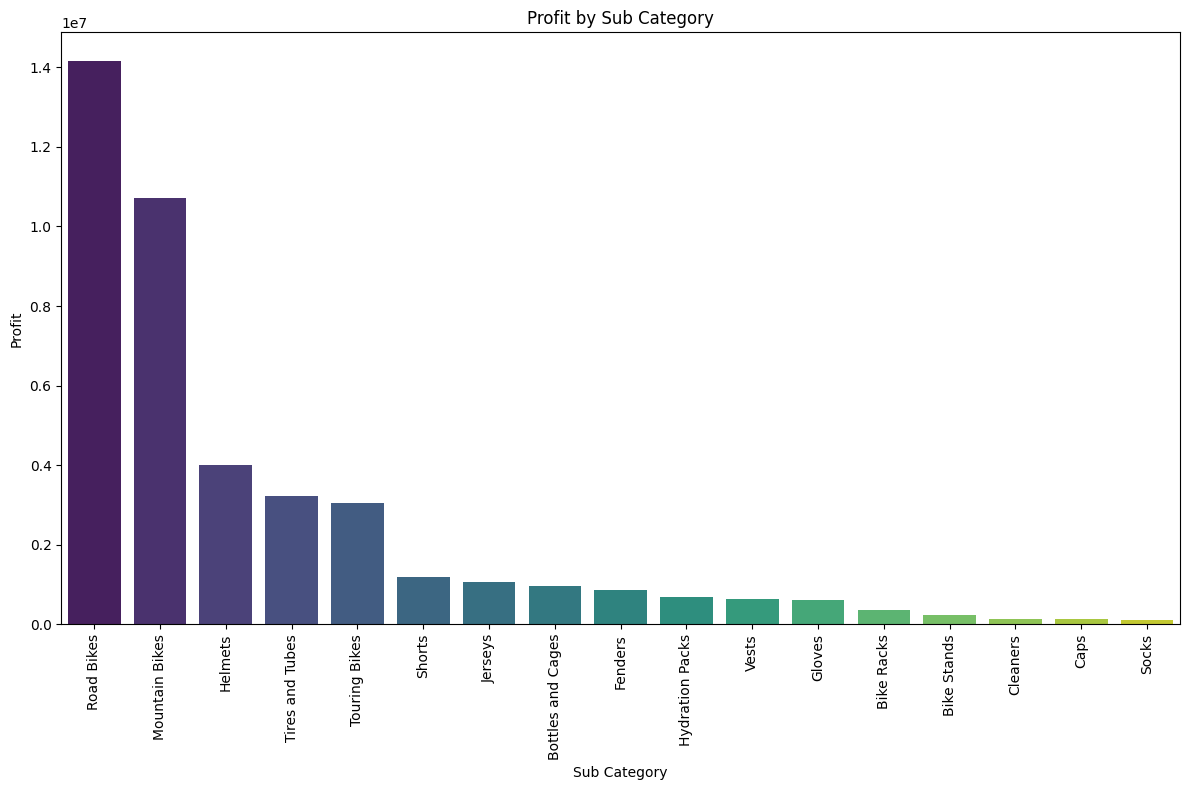

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(x=products.index, y=products['Profit'], palette='viridis')
plt.title('Profit by Sub Category')
plt.xlabel('Sub Category')
plt.ylabel('Profit')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

This bar chart visually represents the profit generated by each product sub-category, sorted in descending order of profit. This helps in quickly identifying the top-performing and lowest-performing product categories in terms of profitability.

In [12]:
df.to_csv('Mavis_Cleaned_Data.csv', index=False)